#Adagrad

Epoch 0 | Cost: 0.6852
Epoch 10 | Cost: 0.6654
Epoch 20 | Cost: 0.6634
Epoch 30 | Cost: 0.6613
Epoch 40 | Cost: 0.6616
Epoch 50 | Cost: 0.6613
Epoch 60 | Cost: 0.6599
Epoch 70 | Cost: 0.6605
Epoch 80 | Cost: 0.6609
Epoch 90 | Cost: 0.6597
Epoch 100 | Cost: 0.6597
Epoch 110 | Cost: 0.6610
Epoch 120 | Cost: 0.6595
Epoch 130 | Cost: 0.6604
Epoch 140 | Cost: 0.6609
Epoch 150 | Cost: 0.6595
Epoch 160 | Cost: 0.6594
Epoch 170 | Cost: 0.6594
Epoch 180 | Cost: 0.6595
Epoch 190 | Cost: 0.6595

✅ Test Accuracy (Adagrad): 60.66%


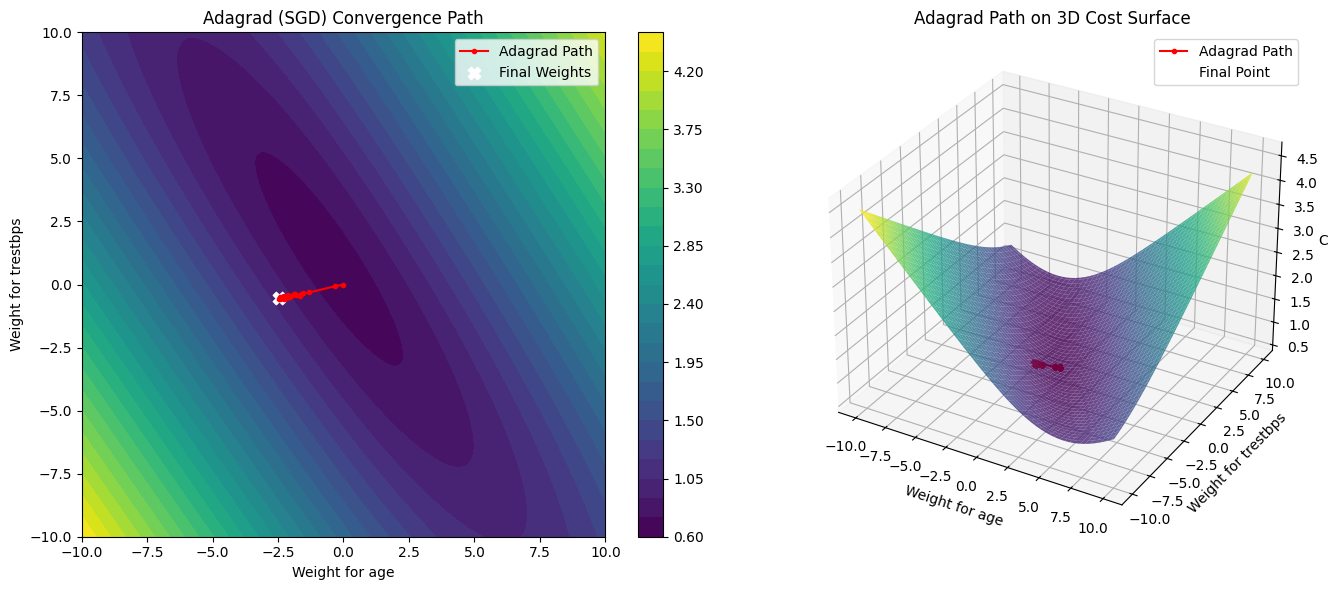

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# ------------------ Load dataset ------------------
df = pd.read_csv("/content/heart_cleaned.csv")

# Choose 2 features for visualization
features = ["age", "trestbps"]
X = df[features].values
y = df["target"].values.reshape(-1, 1)

# Scale features
scaler = MinMaxScaler()
X = scaler.fit_transform(X)

# Add bias term
X_b = np.c_[np.ones((X.shape[0], 1)), X]

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(X_b, y, test_size=0.2, random_state=42)

# ------------------ Helper Functions ------------------
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def compute_cost(y, y_hat):
    m = len(y)
    return -(1/m) * np.sum(y*np.log(y_hat + 1e-8) + (1-y)*np.log(1 - y_hat + 1e-8))

# ------------------ Adagrad (SGD-based) ------------------
def adagrad_sgd_with_path(X, y, lr=0.5, epsilon=1e-8, epochs=200, batch_size=16):
    m, n = X.shape
    W = np.zeros((n, 1))
    G = np.zeros((n, 1))  # Accumulated squared gradients
    costs = []
    path = [W.copy()]

    for epoch in range(epochs):
        indices = np.arange(m)
        np.random.shuffle(indices)
        X = X[indices]
        y = y[indices]

        for i in range(0, m, batch_size):
            X_batch = X[i:i+batch_size]
            y_batch = y[i:i+batch_size]

            # Forward pass
            z = np.dot(X_batch, W)
            y_hat = sigmoid(z)

            # Gradient
            dw = (1 / X_batch.shape[0]) * np.dot(X_batch.T, (y_hat - y_batch))

            # Accumulate squared gradients
            G += dw ** 2

            # Adagrad update
            W -= (lr / (np.sqrt(G) + epsilon)) * dw

            if np.random.rand() < 0.005:
                path.append(W.copy())

        # Compute epoch cost
        y_hat_all = sigmoid(np.dot(X, W))
        cost_epoch = compute_cost(y, y_hat_all)
        costs.append(cost_epoch)

        if epoch % 10 == 0:
            print(f"Epoch {epoch} | Cost: {cost_epoch:.4f}")
            path.append(W.copy())

    return W, np.array(path), costs

# ------------------ Train the model ------------------
W_adagrad, path_adagrad, costs_adagrad = adagrad_sgd_with_path(X_train, y_train, lr=0.5, epochs=200, batch_size=16)

# ------------------ Evaluate ------------------
y_pred_adagrad = sigmoid(np.dot(X_test, W_adagrad))
y_pred_class_adagrad = (y_pred_adagrad >= 0.5).astype(int)
accuracy_adagrad = np.mean(y_pred_class_adagrad == y_test) * 100
print(f"\n✅ Test Accuracy (Adagrad): {accuracy_adagrad:.2f}%")

# ------------------ Compute Cost Surface ------------------
w1 = np.linspace(-10, 10, 100)
w2 = np.linspace(-10, 10, 100)
W1, W2 = np.meshgrid(w1, w2)
cost_surface = np.zeros_like(W1)

for i in range(W1.shape[0]):
    for j in range(W1.shape[1]):
        W_temp = np.array([[0], [W1[i, j]], [W2[i, j]]])  # bias, w1, w2
        z = np.dot(X_train[:, :3], W_temp)
        y_hat = sigmoid(z)
        cost_surface[i, j] = compute_cost(y_train, y_hat)

# ------------------ Plot Contour + 3D with Adagrad Path ------------------
fig = plt.figure(figsize=(14, 6))

# 2D Contour Plot
ax1 = fig.add_subplot(1, 2, 1)
cp = ax1.contourf(W1, W2, cost_surface, levels=30, cmap='viridis')
ax1.set_title("Adagrad (SGD) Convergence Path", fontsize=12)
ax1.set_xlabel("Weight for age")
ax1.set_ylabel("Weight for trestbps")
ax1.plot(path_adagrad[:, 1], path_adagrad[:, 2], color='red', marker='o', markersize=3, linewidth=1.5, label='Adagrad Path')
ax1.scatter(W_adagrad[1], W_adagrad[2], color='white', marker='X', s=80, label='Final Weights')
ax1.legend()
fig.colorbar(cp, ax=ax1)

# 3D Surface Plot
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.plot_surface(W1, W2, cost_surface, cmap='viridis', alpha=0.8)
ax2.set_title("Adagrad Path on 3D Cost Surface", fontsize=12)
ax2.set_xlabel("Weight for age")
ax2.set_ylabel("Weight for trestbps")
ax2.set_zlabel("Cost")

z_path = []
for Wp in path_adagrad:
    z = np.dot(X_train[:, :3], Wp)
    y_hat = sigmoid(z)
    z_path.append(compute_cost(y_train, y_hat))
z_path = np.array(z_path)

ax2.plot(path_adagrad[:, 1], path_adagrad[:, 2], z_path, color='red', marker='o', markersize=3, linewidth=1.5, label='Adagrad Path')
ax2.scatter(W_adagrad[1], W_adagrad[2], z_path[-1], color='white', marker='X', s=60, label='Final Point')
ax2.legend()

plt.tight_layout()
plt.show()

Adagrad (SGD) Overview — 2 to 3 Points

Adapts learning rate automatically for each weight by dividing the gradient by the square root of accumulated past gradients.

Penalizes large and frequently updated weights, so the algorithm takes smaller steps in those directions.

Helps in faster and more stable convergence, especially when features have different scales.

#RMSProp

Epoch 0 | Cost: 0.6929
Epoch 5 | Cost: 0.6794
Epoch 10 | Cost: 0.6750
Epoch 15 | Cost: 0.6691
Epoch 20 | Cost: 0.6674
Epoch 25 | Cost: 0.6656
Epoch 30 | Cost: 0.6647
Epoch 35 | Cost: 0.6637
Epoch 40 | Cost: 0.6640
Epoch 45 | Cost: 0.6639

✅ Test Accuracy (RMSProp-SGD): 60.66%


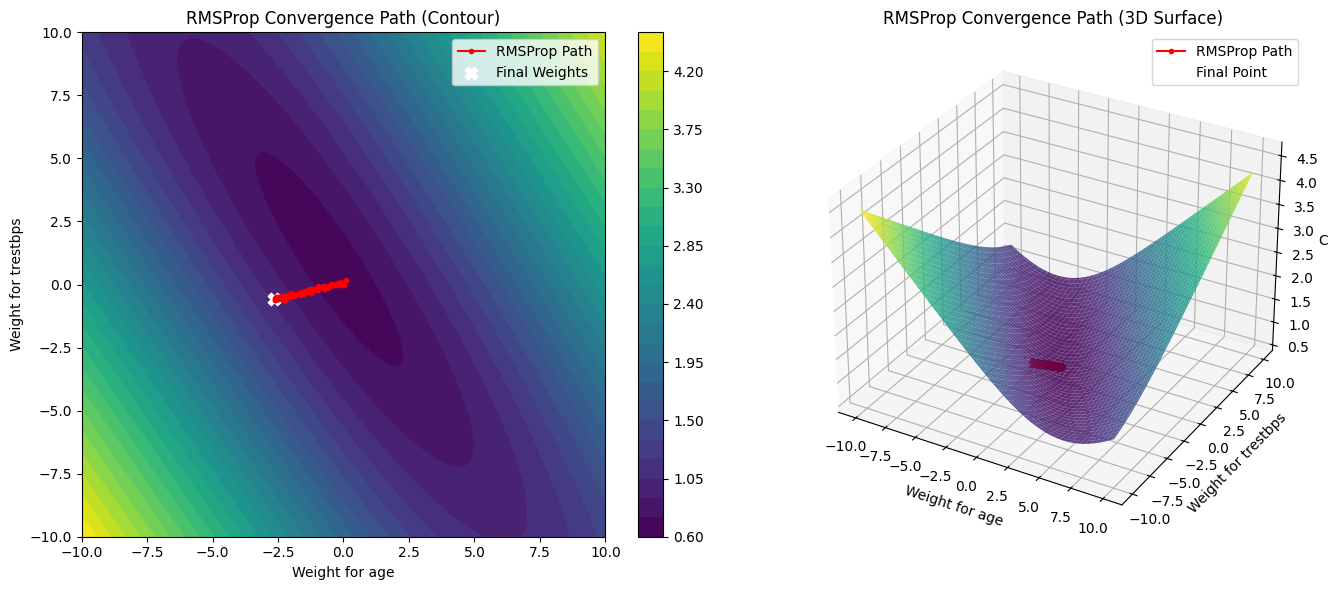

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# ------------------ Load dataset ------------------
df = pd.read_csv("/content/heart_cleaned.csv")

# Select only two features for visualization
features = ["age", "trestbps"]   # choose 2 features
X = df[features].values
y = df["target"].values.reshape(-1, 1)

# Scale features (if not already scaled)
scaler = MinMaxScaler()
X = scaler.fit_transform(X)

# Add bias term
X_b = np.c_[np.ones((X.shape[0], 1)), X]

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X_b, y, test_size=0.2, random_state=42)

# ------------------ Helper functions ------------------
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def compute_cost(y, y_hat):
    m = len(y)
    return -(1/m) * np.sum(y * np.log(y_hat + 1e-8) + (1 - y) * np.log(1 - y_hat + 1e-8))

# ------------------ RMSProp (SGD) with path recording ------------------
def rmsprop_sgd_with_path(X, y, lr=0.01, beta=0.9, epsilon=1e-8, epochs=50):
    m, n = X.shape
    W = np.zeros((n, 1))
    s_W = np.zeros((n, 1))
    path = [W.copy()]
    costs = []

    for epoch in range(epochs):
        indices = np.arange(m)
        np.random.shuffle(indices)
        total_cost = 0

        for i in indices:
            xi = X[i].reshape(1, -1)
            yi = y[i]

            # Forward
            z = np.dot(xi, W)
            y_hat = sigmoid(z)

            # Gradients
            dw = np.dot(xi.T, (y_hat - yi))

            # RMSProp updates
            s_W = beta * s_W + (1 - beta) * (dw ** 2)
            W -= (lr / (np.sqrt(s_W) + epsilon)) * dw

            total_cost += compute_cost(yi, y_hat)

            # Occasionally record path
            if np.random.rand() < 0.01:
                path.append(W.copy())

        avg_cost = total_cost / m
        costs.append(avg_cost)

        if epoch % 5 == 0:
            print(f"Epoch {epoch} | Cost: {avg_cost:.4f}")
            path.append(W.copy())

    return W, np.array(path), costs

# ------------------ Train the model ------------------
W_rms, path_rms, costs_rms = rmsprop_sgd_with_path(X_train, y_train, lr=0.01, beta=0.9, epochs=50)

# ------------------ Evaluate ------------------
y_pred = sigmoid(np.dot(X_test, W_rms))
y_pred_class = (y_pred >= 0.5).astype(int)
accuracy = np.mean(y_pred_class == y_test) * 100
print(f"\n✅ Test Accuracy (RMSProp-SGD): {accuracy:.2f}%")

# ------------------ Compute Cost Surface ------------------
w1 = np.linspace(-10, 10, 100)
w2 = np.linspace(-10, 10, 100)
W1, W2 = np.meshgrid(w1, w2)
cost_surface = np.zeros_like(W1)

for i in range(W1.shape[0]):
    for j in range(W1.shape[1]):
        W_temp = np.array([[0], [W1[i, j]], [W2[i, j]]])
        z = np.dot(X_train[:, :3], W_temp)
        y_hat = sigmoid(z)
        cost_surface[i, j] = compute_cost(y_train, y_hat)

# ------------------ Plot Contour and 3D with RMSProp Path ------------------
fig = plt.figure(figsize=(14, 6))

# Contour Plot
ax1 = fig.add_subplot(1, 2, 1)
cp = ax1.contourf(W1, W2, cost_surface, levels=30, cmap='viridis')
ax1.set_title("RMSProp Convergence Path (Contour)", fontsize=12)
ax1.set_xlabel("Weight for age")
ax1.set_ylabel("Weight for trestbps")

# Plot Path
ax1.plot(path_rms[:, 1], path_rms[:, 2], color='red', marker='o', markersize=3, linewidth=1.5, label='RMSProp Path')
ax1.scatter(W_rms[1], W_rms[2], color='white', marker='X', s=80, label='Final Weights')
ax1.legend()
fig.colorbar(cp, ax=ax1)

# 3D Surface Plot
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.plot_surface(W1, W2, cost_surface, cmap='viridis', alpha=0.85)
ax2.set_title("RMSProp Convergence Path (3D Surface)", fontsize=12)
ax2.set_xlabel("Weight for age")
ax2.set_ylabel("Weight for trestbps")
ax2.set_zlabel("Cost")

# 3D Path
z_path = []
for Wp in path_rms:
    z = np.dot(X_train[:, :3], Wp)
    y_hat = sigmoid(z)
    z_path.append(compute_cost(y_train, y_hat))
z_path = np.array(z_path)

ax2.plot(path_rms[:, 1], path_rms[:, 2], z_path, color='red', marker='o', markersize=3, linewidth=1.5, label='RMSProp Path')
ax2.scatter(W_rms[1], W_rms[2], z_path[-1], color='white', marker='X', s=60, label='Final Point')
ax2.legend()

plt.tight_layout()
plt.show()


RMSProp keeps an exponentially decaying average of squared gradients, so it smoothly adapts the learning rate for each weight.

It penalizes directions with consistently large gradients, preventing oscillation and making training more stable.

Works well on noisy mini-batch SGD and helps the optimization move faster along good directions and slower along steep directions.

#Adam

Epoch 0 | Cost: 0.6886
Epoch 10 | Cost: 0.6704
Epoch 20 | Cost: 0.6659
Epoch 30 | Cost: 0.6644
Epoch 40 | Cost: 0.6606
Epoch 50 | Cost: 0.6634
Epoch 60 | Cost: 0.6600
Epoch 70 | Cost: 0.6598
Epoch 80 | Cost: 0.6605
Epoch 90 | Cost: 0.6595
Epoch 100 | Cost: 0.6596
Epoch 110 | Cost: 0.6618
Epoch 120 | Cost: 0.6603
Epoch 130 | Cost: 0.6637
Epoch 140 | Cost: 0.6595
Epoch 150 | Cost: 0.6605
Epoch 160 | Cost: 0.6597
Epoch 170 | Cost: 0.6606
Epoch 180 | Cost: 0.6596
Epoch 190 | Cost: 0.6685

✅ Test Accuracy (Adam): 62.30%


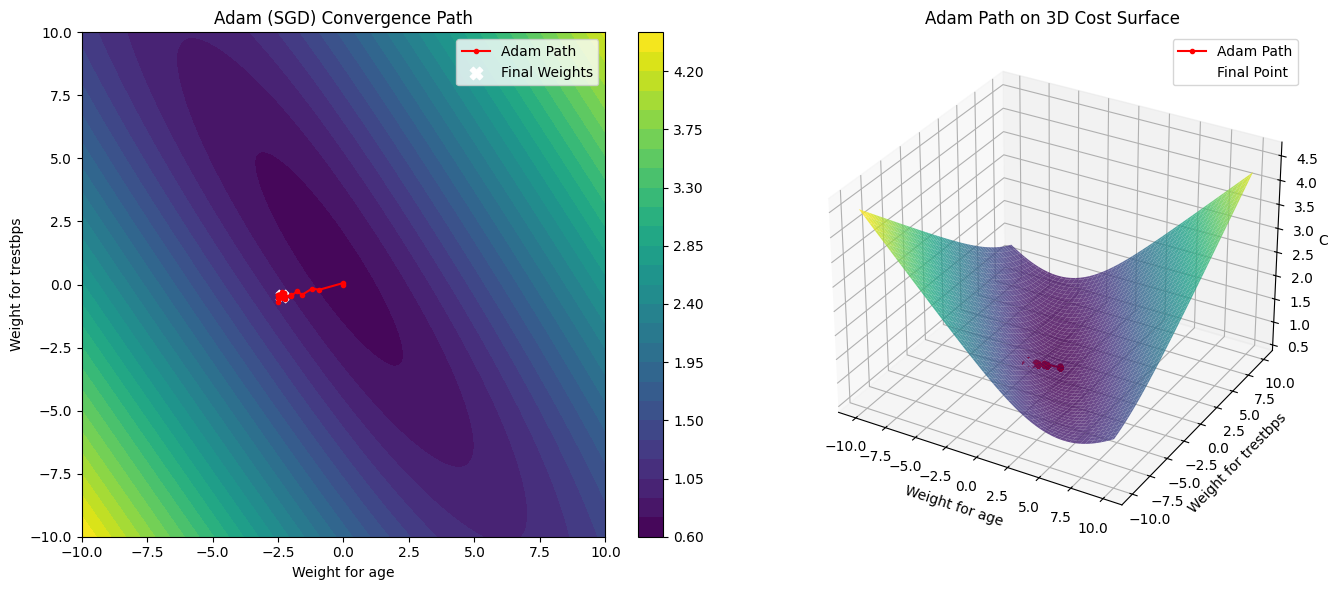

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# ------------------ Load dataset ------------------
df = pd.read_csv("/content/heart_cleaned.csv")

# Choose 2 features for visualization
features = ["age", "trestbps"]
X = df[features].values
y = df["target"].values.reshape(-1, 1)

# Scale features
scaler = MinMaxScaler()
X = scaler.fit_transform(X)

# Add bias term
X_b = np.c_[np.ones((X.shape[0], 1)), X]

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(
    X_b, y, test_size=0.2, random_state=42
)

# ------------------ Helper Functions ------------------
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def compute_cost(y, y_hat):
    m = len(y)
    return -(1/m) * np.sum(y*np.log(y_hat + 1e-8) + (1-y)*np.log(1 - y_hat + 1e-8))

# ------------------ Adam (SGD-based) ------------------
def adam_sgd_with_path(X, y, lr=0.01, beta1=0.9, beta2=0.999, epsilon=1e-8, epochs=200, batch_size=16):
    m, n = X.shape
    W = np.zeros((n, 1))
    m_t = np.zeros((n, 1))  # First moment
    v_t = np.zeros((n, 1))  # Second moment
    costs = []
    path = [W.copy()]

    t = 0
    for epoch in range(epochs):
        indices = np.arange(m)
        np.random.shuffle(indices)
        X = X[indices]
        y = y[indices]

        for i in range(0, m, batch_size):
            t += 1
            X_batch = X[i:i+batch_size]
            y_batch = y[i:i+batch_size]

            # Forward pass
            z = np.dot(X_batch, W)
            y_hat = sigmoid(z)

            # Gradient
            dw = (1 / X_batch.shape[0]) * np.dot(X_batch.T, (y_hat - y_batch))

            # Update biased first and second moments
            m_t = beta1 * m_t + (1 - beta1) * dw
            v_t = beta2 * v_t + (1 - beta2) * (dw ** 2)

            # Correct bias
            m_hat = m_t / (1 - beta1 ** t)
            v_hat = v_t / (1 - beta2 ** t)

            # Parameter update
            W -= lr * m_hat / (np.sqrt(v_hat) + epsilon)

            if np.random.rand() < 0.005:
                path.append(W.copy())

        # Compute epoch cost
        y_hat_all = sigmoid(np.dot(X, W))
        cost_epoch = compute_cost(y, y_hat_all)
        costs.append(cost_epoch)

        if epoch % 10 == 0:
            print(f"Epoch {epoch} | Cost: {cost_epoch:.4f}")
            path.append(W.copy())

    return W, np.array(path), costs

# ------------------ Train the model ------------------
W_adam, path_adam, costs_adam = adam_sgd_with_path(
    X_train, y_train, lr=0.05, epochs=200, batch_size=16
)

# ------------------ Evaluate ------------------
y_pred_adam = sigmoid(np.dot(X_test, W_adam))
y_pred_class_adam = (y_pred_adam >= 0.5).astype(int)
accuracy_adam = np.mean(y_pred_class_adam == y_test) * 100
print(f"\n✅ Test Accuracy (Adam): {accuracy_adam:.2f}%")

# ------------------ Compute Cost Surface ------------------
w1 = np.linspace(-10, 10, 100)
w2 = np.linspace(-10, 10, 100)
W1, W2 = np.meshgrid(w1, w2)
cost_surface = np.zeros_like(W1)

for i in range(W1.shape[0]):
    for j in range(W1.shape[1]):
        W_temp = np.array([[0], [W1[i, j]], [W2[i, j]]])  # bias, w1, w2
        z = np.dot(X_train[:, :3], W_temp)
        y_hat = sigmoid(z)
        cost_surface[i, j] = compute_cost(y_train, y_hat)

# ------------------ Plot Contour + 3D with Adam Path ------------------
fig = plt.figure(figsize=(14, 6))

# 2D Contour Plot
ax1 = fig.add_subplot(1, 2, 1)
cp = ax1.contourf(W1, W2, cost_surface, levels=30, cmap='viridis')
ax1.set_title("Adam (SGD) Convergence Path", fontsize=12)
ax1.set_xlabel("Weight for age")
ax1.set_ylabel("Weight for trestbps")
ax1.plot(path_adam[:, 1], path_adam[:, 2], color='red', marker='o', markersize=3, linewidth=1.5, label='Adam Path')
ax1.scatter(W_adam[1], W_adam[2], color='white', marker='X', s=80, label='Final Weights')
ax1.legend()
fig.colorbar(cp, ax=ax1)

# 3D Surface Plot
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.plot_surface(W1, W2, cost_surface, cmap='viridis', alpha=0.8)
ax2.set_title("Adam Path on 3D Cost Surface", fontsize=12)
ax2.set_xlabel("Weight for age")
ax2.set_ylabel("Weight for trestbps")
ax2.set_zlabel("Cost")

# Compute z_path for the 3D plot
z_path = []
for Wp in path_adam:
    z = np.dot(X_train[:, :3], Wp)
    y_hat = sigmoid(z)
    z_path.append(compute_cost(y_train, y_hat))
z_path = np.array(z_path)

ax2.plot(path_adam[:, 1], path_adam[:, 2], z_path, color='red', marker='o', markersize=3, linewidth=1.5, label='Adam Path')
ax2.scatter(W_adam[1], W_adam[2], z_path[-1], color='white', marker='X', s=60, label='Final Point')
ax2.legend()

plt.tight_layout()
plt.show()

Combines Momentum (first moment) and RMSProp (second moment), so it adapts both the direction and step size of learning.

Applies bias correction, which makes updates stable even in early iterations.

Provides fast, smooth, and reliable convergence, especially on noisy mini-batch SGD.

#Plots for all algorithms (Momentum, Adam, RMSProp)

[Momentum] Epoch 0 | Cost: 0.6931
[Momentum] Epoch 5 | Cost: 0.6930
[Momentum] Epoch 10 | Cost: 0.6926
[Momentum] Epoch 15 | Cost: 0.6922
[Momentum] Epoch 20 | Cost: 0.6918
[Momentum] Epoch 25 | Cost: 0.6914
[Momentum] Epoch 30 | Cost: 0.6910
[Momentum] Epoch 35 | Cost: 0.6907
[Momentum] Epoch 40 | Cost: 0.6904
[Momentum] Epoch 45 | Cost: 0.6901
[Momentum] Epoch 50 | Cost: 0.6898
[Momentum] Epoch 55 | Cost: 0.6896
[Momentum] Epoch 60 | Cost: 0.6894
[Momentum] Epoch 65 | Cost: 0.6892
[Momentum] Epoch 70 | Cost: 0.6891
[Momentum] Epoch 75 | Cost: 0.6889
[Momentum] Epoch 80 | Cost: 0.6888
[Momentum] Epoch 85 | Cost: 0.6887
[Momentum] Epoch 90 | Cost: 0.6885
[Momentum] Epoch 95 | Cost: 0.6884
[Momentum] Epoch 100 | Cost: 0.6883
[Momentum] Epoch 105 | Cost: 0.6882
[Momentum] Epoch 110 | Cost: 0.6881
[Momentum] Epoch 115 | Cost: 0.6880
[Momentum] Epoch 120 | Cost: 0.6878
[Momentum] Epoch 125 | Cost: 0.6877
[Momentum] Epoch 130 | Cost: 0.6876
[Momentum] Epoch 135 | Cost: 0.6875
[Momentum] Epo

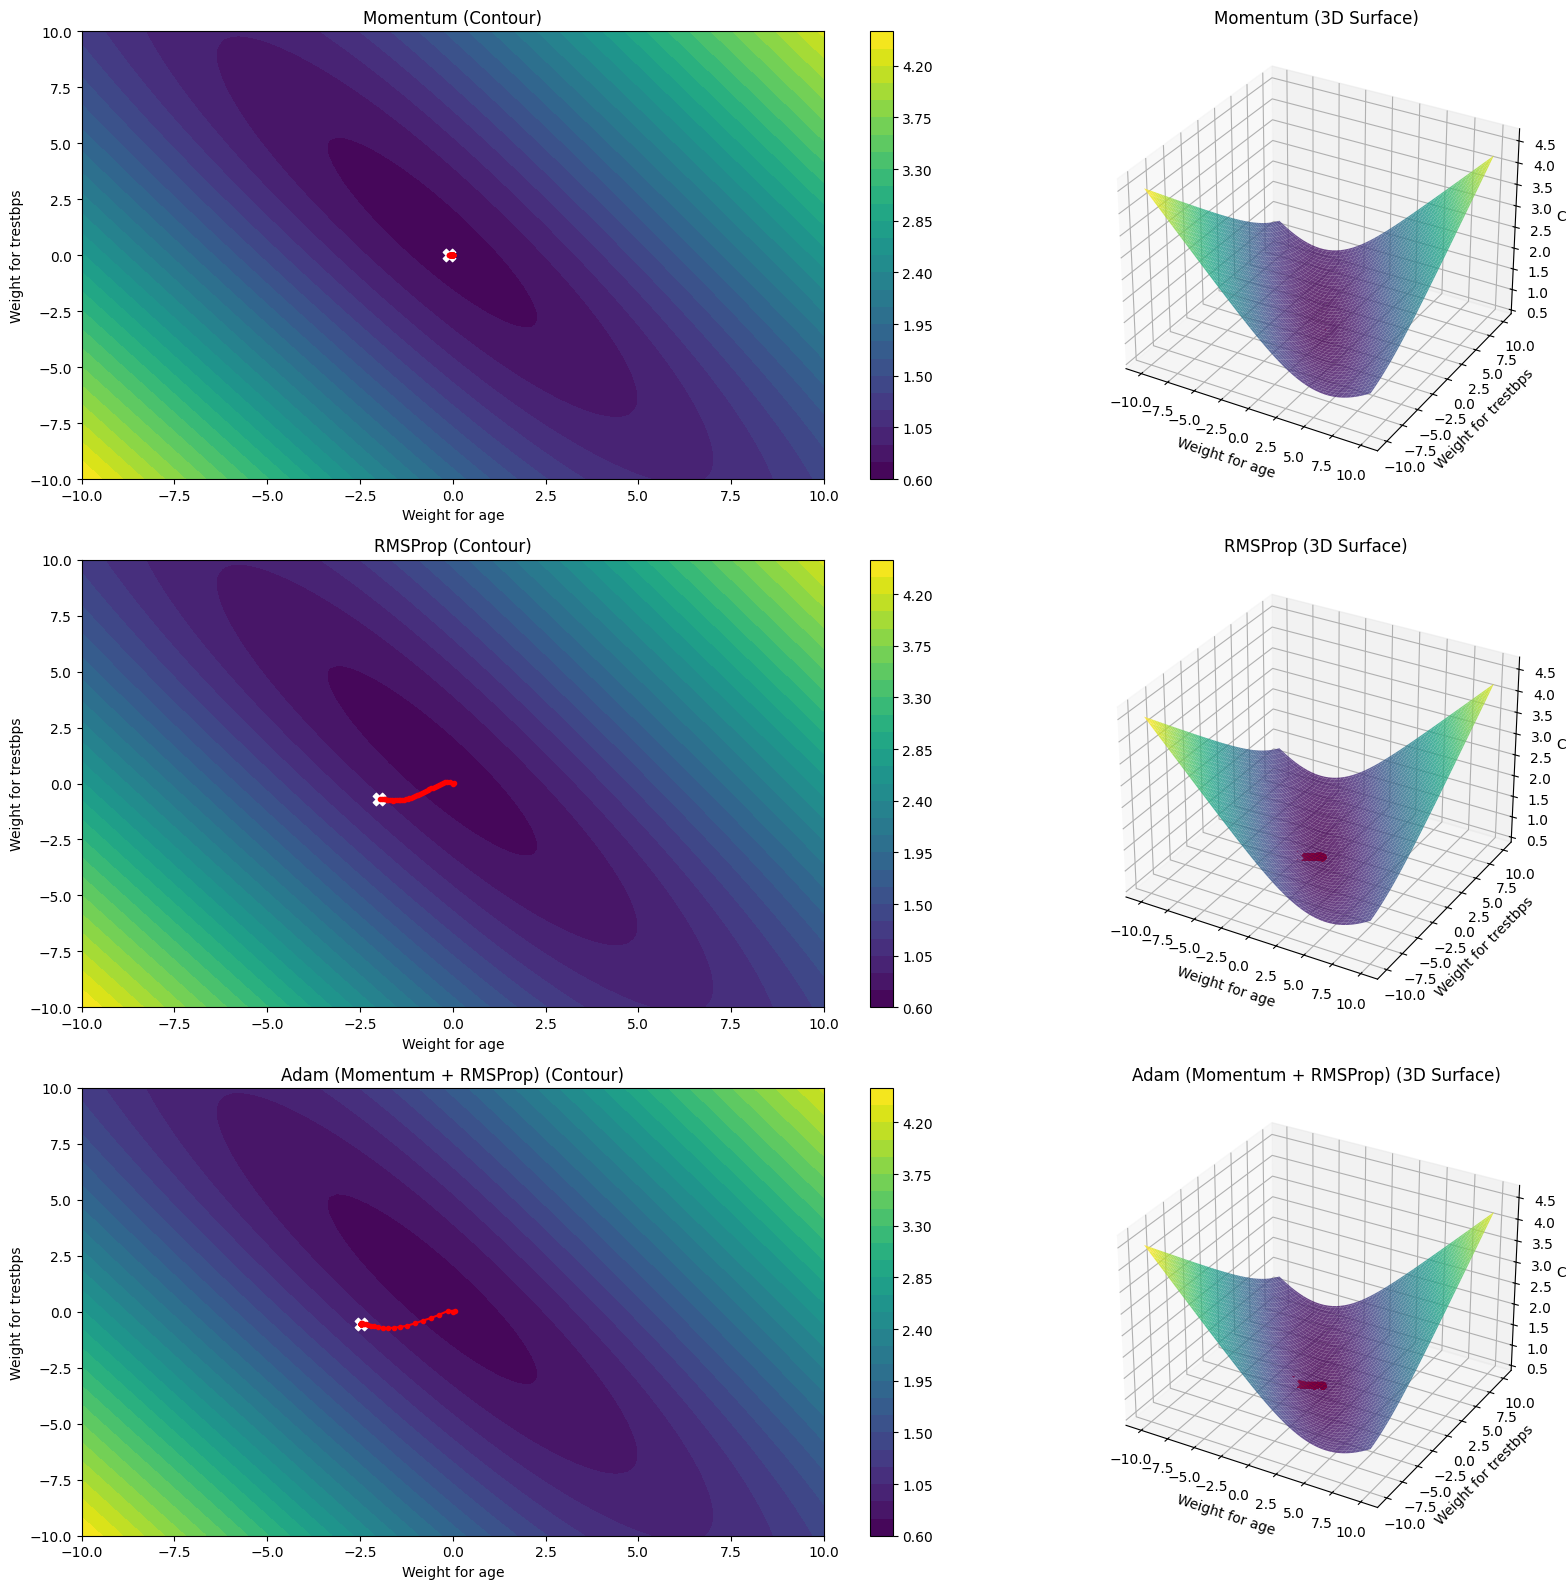

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# ------------------ Load dataset ------------------
df = pd.read_csv("/content/heart_cleaned.csv")

# Choose two features for visualization
features = ["age", "trestbps"]
X = df[features].values
y = df["target"].values.reshape(-1, 1)

# Scale features
scaler = MinMaxScaler()
X = scaler.fit_transform(X)

# Add bias term
X_b = np.c_[np.ones((X.shape[0], 1)), X]

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(X_b, y, test_size=0.2, random_state=42)

# ------------------ Helper Functions ------------------
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def compute_cost(y, y_hat):
    m = len(y)
    return -(1/m) * np.sum(y*np.log(y_hat + 1e-8) + (1-y)*np.log(1 - y_hat + 1e-8))

# ------------------ 1️⃣ Momentum Optimizer ------------------
def momentum_optimizer_with_path(X, y, lr=0.05, beta=0.9, epochs=200):
    m, n = X.shape
    W = np.zeros((n, 1))
    v = np.zeros((n, 1))
    costs, path = [], [W.copy()]

    for epoch in range(epochs):
        z = np.dot(X, W)
        y_hat = sigmoid(z)
        dw = (1/m) * np.dot(X.T, (y_hat - y))

        v = beta * v + (1 - beta) * dw
        W -= lr * v

        if epoch % 5 == 0:
            cost = compute_cost(y, y_hat)
            costs.append(cost)
            path.append(W.copy())
            print(f"[Momentum] Epoch {epoch} | Cost: {cost:.4f}")

    return W, np.array(path), costs

# ------------------ 2️⃣ RMSProp Optimizer ------------------
def rmsprop_optimizer_with_path(X, y, lr=0.01, beta=0.9, epsilon=1e-8, epochs=200):
    m, n = X.shape
    W = np.zeros((n, 1))
    s = np.zeros((n, 1))
    costs, path = [], [W.copy()]

    for epoch in range(epochs):
        z = np.dot(X, W)
        y_hat = sigmoid(z)
        dw = (1/m) * np.dot(X.T, (y_hat - y))

        s = beta * s + (1 - beta) * (dw ** 2)
        W -= lr * dw / (np.sqrt(s) + epsilon)

        if epoch % 5 == 0:
            cost = compute_cost(y, y_hat)
            costs.append(cost)
            path.append(W.copy())
            print(f"[RMSProp] Epoch {epoch} | Cost: {cost:.4f}")

    return W, np.array(path), costs

# ------------------ 3️⃣ Adam Optimizer ------------------
def adam_optimizer_with_path(X, y, lr=0.01, beta1=0.9, beta2=0.999, epsilon=1e-8, epochs=200):
    m, n = X.shape
    W = np.zeros((n, 1))
    m_t = np.zeros((n, 1))
    v_t = np.zeros((n, 1))
    costs, path = [], [W.copy()]

    for epoch in range(epochs):
        z = np.dot(X, W)
        y_hat = sigmoid(z)
        dw = (1/m) * np.dot(X.T, (y_hat - y))

        m_t = beta1 * m_t + (1 - beta1) * dw
        v_t = beta2 * v_t + (1 - beta2) * (dw ** 2)

        m_hat = m_t / (1 - beta1 ** (epoch + 1))
        v_hat = v_t / (1 - beta2 ** (epoch + 1))

        W -= lr * m_hat / (np.sqrt(v_hat) + epsilon)

        if epoch % 5 == 0:
            cost = compute_cost(y, y_hat)
            costs.append(cost)
            path.append(W.copy())
            print(f"[Adam] Epoch {epoch} | Cost: {cost:.4f}")

    return W, np.array(path), costs

# ------------------ Train Each Optimizer ------------------
W_mom, path_mom, _ = momentum_optimizer_with_path(X_train, y_train, lr=0.05, epochs=200)
W_rms, path_rms, _ = rmsprop_optimizer_with_path(X_train, y_train, lr=0.01, epochs=200)
W_adam, path_adam, _ = adam_optimizer_with_path(X_train, y_train, lr=0.05, epochs=200)

# ------------------ Compute Cost Surface ------------------
w1 = np.linspace(-10, 10, 100)
w2 = np.linspace(-10, 10, 100)
W1, W2 = np.meshgrid(w1, w2)
cost_surface = np.zeros_like(W1)

for i in range(W1.shape[0]):
    for j in range(W1.shape[1]):
        W_temp = np.array([[0], [W1[i, j]], [W2[i, j]]])
        z = np.dot(X_train[:, :3], W_temp)
        y_hat = sigmoid(z)
        cost_surface[i, j] = compute_cost(y_train, y_hat)

# ------------------ Plot Function ------------------
def plot_optimizer(ax1, ax2, path, W_final, title):
    # Contour plot
    cp = ax1.contourf(W1, W2, cost_surface, levels=30, cmap='viridis')
    ax1.plot(path[:, 1], path[:, 2], color='red', marker='o', markersize=3, linewidth=1.5)
    ax1.scatter(W_final[1], W_final[2], color='white', marker='X', s=80)
    ax1.set_title(f"{title} (Contour)", fontsize=12)
    ax1.set_xlabel("Weight for age")
    ax1.set_ylabel("Weight for trestbps")
    fig.colorbar(cp, ax=ax1)

    # 3D plot
    ax2.plot_surface(W1, W2, cost_surface, cmap='viridis', alpha=0.8)
    z_path = []
    for Wp in path:
        z = np.dot(X_train[:, :3], Wp)
        y_hat = sigmoid(z)
        z_path.append(compute_cost(y_train, y_hat))
    z_path = np.array(z_path)
    ax2.plot(path[:, 1], path[:, 2], z_path, color='red', marker='o', markersize=3, linewidth=1.5)
    ax2.scatter(W_final[1], W_final[2], z_path[-1], color='white', marker='X', s=60)
    ax2.set_title(f"{title} (3D Surface)", fontsize=12)
    ax2.set_xlabel("Weight for age")
    ax2.set_ylabel("Weight for trestbps")
    ax2.set_zlabel("Cost")

# ------------------ Visualization ------------------
fig = plt.figure(figsize=(18, 16))

# Momentum
ax1 = fig.add_subplot(3, 2, 1)
ax2 = fig.add_subplot(3, 2, 2, projection='3d')
plot_optimizer(ax1, ax2, path_mom, W_mom, "Momentum")

# RMSProp
ax3 = fig.add_subplot(3, 2, 3)
ax4 = fig.add_subplot(3, 2, 4, projection='3d')
plot_optimizer(ax3, ax4, path_rms, W_rms, "RMSProp")

# Adam
ax5 = fig.add_subplot(3, 2, 5)
ax6 = fig.add_subplot(3, 2, 6, projection='3d')
plot_optimizer(ax5, ax6, path_adam, W_adam, "Adam (Momentum + RMSProp)")

plt.tight_layout()
plt.show()


#Combined Contour Plot for all algorithms

Training AdaGrad, RMSProp, and Adam...


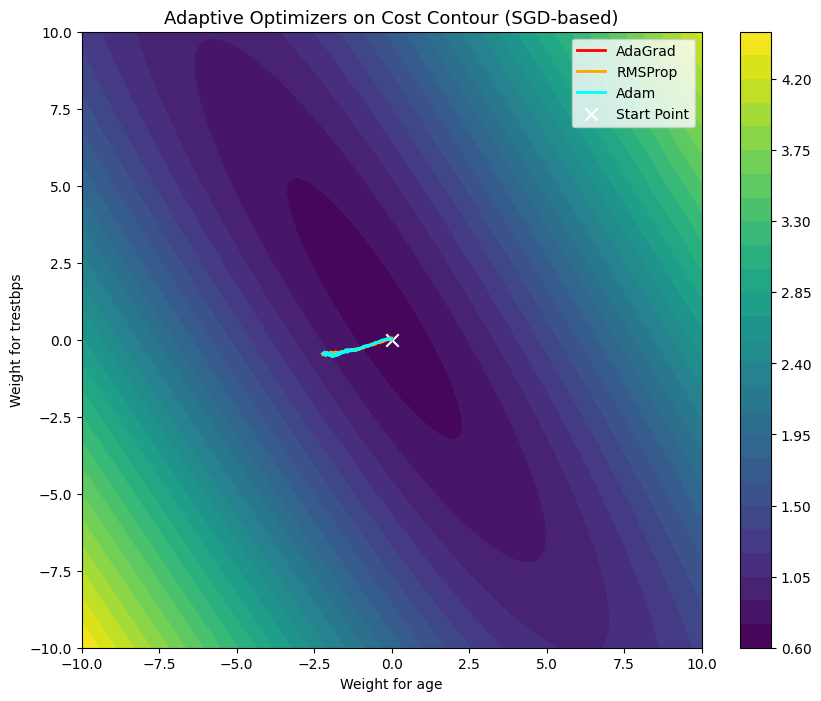

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# ------------------ Load Dataset ------------------
df = pd.read_csv("/content/heart_cleaned.csv")
features = ["age", "trestbps"]
X = df[features].values
y = df["target"].values.reshape(-1, 1)

# Scale features
scaler = MinMaxScaler()
X = scaler.fit_transform(X)
X_b = np.c_[np.ones((X.shape[0], 1)), X]

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(
    X_b, y, test_size=0.2, random_state=42
)

# ------------------ Helper Functions ------------------
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def compute_cost(y, y_hat):
    m = len(y)
    return -(1/m) * np.sum(y*np.log(y_hat + 1e-8) + (1-y)*np.log(1 - y_hat + 1e-8))

def gradient(X, y, W):
    y_hat = sigmoid(np.dot(X, W))
    return (1 / len(y)) * np.dot(X.T, (y_hat - y))

# ------------------ AdaGrad (SGD-based) ------------------
def adagrad(X, y, lr=0.1, epsilon=1e-8, epochs=200, batch_size=16):
    m, n = X.shape
    W = np.zeros((n, 1))
    G = np.zeros((n, 1))  # Accumulated squared gradients
    path = [W.copy()]

    for epoch in range(epochs):
        indices = np.arange(m)
        np.random.shuffle(indices)
        X = X[indices]
        y = y[indices]
        for i in range(0, m, batch_size):
            Xb = X[i:i+batch_size]
            yb = y[i:i+batch_size]
            grad = gradient(Xb, yb, W)
            G += grad**2
            W -= (lr / (np.sqrt(G) + epsilon)) * grad
        path.append(W.copy())
    return np.array(path)

# ------------------ RMSProp (SGD-based) ------------------
def rmsprop(X, y, lr=0.01, beta=0.9, epsilon=1e-8, epochs=200, batch_size=16):
    m, n = X.shape
    W = np.zeros((n, 1))
    Eg2 = np.zeros((n, 1))  # Moving average of squared gradients
    path = [W.copy()]

    for epoch in range(epochs):
        indices = np.arange(m)
        np.random.shuffle(indices)
        X = X[indices]
        y = y[indices]
        for i in range(0, m, batch_size):
            Xb = X[i:i+batch_size]
            yb = y[i:i+batch_size]
            grad = gradient(Xb, yb, W)
            Eg2 = beta * Eg2 + (1 - beta) * grad**2
            W -= lr * grad / (np.sqrt(Eg2) + epsilon)
        path.append(W.copy())
    return np.array(path)

# ------------------ Adam (SGD-based) ------------------
def adam(X, y, lr=0.01, beta1=0.9, beta2=0.999, epsilon=1e-8, epochs=200, batch_size=16):
    m, n = X.shape
    W = np.zeros((n, 1))
    m_t = np.zeros((n, 1))  # First moment
    v_t = np.zeros((n, 1))  # Second moment
    path = [W.copy()]
    t = 0

    for epoch in range(epochs):
        indices = np.arange(m)
        np.random.shuffle(indices)
        X = X[indices]
        y = y[indices]

        for i in range(0, m, batch_size):
            t += 1
            Xb = X[i:i+batch_size]
            yb = y[i:i+batch_size]
            grad = gradient(Xb, yb, W)

            # Update biased moments
            m_t = beta1 * m_t + (1 - beta1) * grad
            v_t = beta2 * v_t + (1 - beta2) * (grad ** 2)

            # Bias correction
            m_hat = m_t / (1 - beta1 ** t)
            v_hat = v_t / (1 - beta2 ** t)

            # Parameter update
            W -= lr * m_hat / (np.sqrt(v_hat) + epsilon)
        path.append(W.copy())
    return np.array(path)

# ------------------ Train Optimizers ------------------
print("Training AdaGrad, RMSProp, and Adam...")
paths = {
    "AdaGrad": adagrad(X_train, y_train),
    "RMSProp": rmsprop(X_train, y_train),
    "Adam": adam(X_train, y_train)
}

# ------------------ Compute Cost Surface ------------------
w1 = np.linspace(-10, 10, 100)
w2 = np.linspace(-10, 10, 100)
W1, W2 = np.meshgrid(w1, w2)
cost_surface = np.zeros_like(W1)

for i in range(W1.shape[0]):
    for j in range(W1.shape[1]):
        W_temp = np.array([[0], [W1[i, j]], [W2[i, j]]])
        z = np.dot(X_train[:, :3], W_temp)
        y_hat = sigmoid(z)
        cost_surface[i, j] = compute_cost(y_train, y_hat)

# ------------------ Plot Contour with Paths ------------------
plt.figure(figsize=(10, 8))
cp = plt.contourf(W1, W2, cost_surface, levels=30, cmap='viridis')
plt.colorbar(cp)
plt.title("Adaptive Optimizers on Cost Contour (SGD-based)", fontsize=13)
plt.xlabel("Weight for age")
plt.ylabel("Weight for trestbps")

colors = ["red", "orange", "cyan"]
for (name, path), color in zip(paths.items(), colors):
    plt.plot(path[:, 1], path[:, 2], color=color, linewidth=2, label=name)

plt.scatter(0, 0, color="white", marker="x", s=80, label="Start Point")
plt.legend()
plt.show()